## Similarity and clustering
### Theme Mining & Semantic Similarity with Word2Vec:
In this section, we convert customer reviews into numerical vectors using Word2Vec.  
These vectors help us group similar reviews together and retrieve meaningfully related feedback, not just keyword matches.  
Clustering reveals common customer themes, and cosine similarity helps us find reviews expressing similar experiences.


## Install Dependencies and Import Libraries

In [ ]:
!pip install gensim   #for word2vec model

In [ ]:
import numpy as np
import pandas as pd
from gensim.models import Word2Vec # Import Word2Vec

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## Load Data

In [ ]:
# Load Preprocessed Dataset
final = pd.read_csv("/content/preprocessed_reviews1.csv")
final.head()


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,CleanedText
0,150524,0006641040,ACITT7DI6IDDL,shari zychinski,0,0,positive,939340800,EVERY book is educational,this witty little book makes my son laugh at l...,witty little book makes son laugh loud recite ...
1,150506,0006641040,A2IW4PEEKO2R0U,Tracy,1,1,positive,1194739200,"Love the book, miss the hard cover version","I grew up reading these Sendak books, and watc...",grew reading sendak books watching really rosi...
2,150507,0006641040,A1S4A3IQ2MU7V4,"sally sue ""sally sue""",1,1,positive,1191456000,chicken soup with rice months,This is a fun way for children to learn their ...,fun way children learn months year learn poems...
3,150508,0006641040,AZGXZ2UUK6X,"Catherine Hallberg ""(Kate)""",1,1,positive,1076025600,a good swingy rhythm for reading aloud,This is a great little book to read aloud- it ...,great little book read aloud nice rhythm well ...
4,150509,0006641040,A3CMRKGE0P909G,Teresa,3,4,positive,1018396800,A great way to learn the months,This is a book of poetry about the months of t...,book poetry months year goes month cute little...


## Tokenization
We break each cleaned review into a list of word tokens.  
These token sequences are the input for Word2Vec, which will learn word relationships from context.

In [ ]:
tokenized_reviews = [word_tokenize(text) for text in final['CleanedText'].dropna() if isinstance(text, str)]
print("Example tokenized review:", tokenized_reviews[0][:20])

Example tokenized review: ['witty', 'little', 'book', 'makes', 'son', 'laugh', 'loud', 'recite', 'car', 'driving', 'along', 'always', 'sing', 'refrain', 'learned', 'whales', 'india', 'drooping', 'roses', 'love']


## Train the Word2Vec Model
Now we train a Word2Vec model on the tokenized reviews.  
This lets us represent each word as a dense vector where similar words (like “tasty” and “delicious”) end up close to each other in vector space.


In [ ]:
#sample_reviews = tokenized_reviews[:50000]  # first 50K reviews
sample_reviews = tokenized_reviews  # use all reviews

In [ ]:
w2v_model = Word2Vec(sentences=sample_reviews, vector_size=50, window=5, min_count=3, workers=4, sg=1)

## Convert Each Review into a Sentence Vector
To get a single vector per review, we average the embeddings of all words in that review.  
These sentence vectors capture the overall meaning of each review and are used for clustering and similarity search.


In [ ]:
def get_sentence_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

# Use the same subset used for Word2Vec training
sample_reviews = tokenized_reviews
review_vectors = np.array([get_sentence_vector(tokens, w2v_model) for tokens in sample_reviews])

print("Sentence vector shape:", review_vectors.shape)


Sentence vector shape: (294156, 50)


## Cluster Reviews Using K-Means
We apply K-Means clustering to the review vectors to group semantically similar reviews together.  
Each cluster tends to represent a recurring theme in customer feedback, such as taste, packaging, price, or delivery experience.


In [ ]:
num_clusters = 5
kmeans_w2v = KMeans(n_clusters=num_clusters, random_state=42)

# Fit on all review vectors
clusters_w2v = kmeans_w2v.fit_predict(review_vectors)

# Get the indices of the reviews that were used for tokenization (i.e., non-null CleanedText)
non_null_cleaned_text_indices = final['CleanedText'].dropna().index

# Create a pandas Series for the clusters, aligning it with the original DataFrame's indices
cluster_series_aligned = pd.Series(clusters_w2v, index=non_null_cleaned_text_indices)

# Assign clusters back to the original dataframe
# Rows that had NaN in CleanedText will now have NaN in Cluster_Word2Vec
final['Cluster_Word2Vec'] = cluster_series_aligned

# Display cluster distribution
print("Cluster distribution:")
print(final['Cluster_Word2Vec'].value_counts())

# Preview sample reviews and their assigned clusters
final[['CleanedText', 'Cluster_Word2Vec']].head(10)

Cluster distribution:
Cluster_Word2Vec
1.0    85216
2.0    73186
4.0    51847
0.0    45003
3.0    38904
Name: count, dtype: int64


,CleanedText,Cluster_Word2Vec
0,witty little book makes son laugh loud recite ...,2.0
1,grew reading sendak books watching really rosi...,3.0
2,fun way children learn months year learn poems...,3.0
3,great little book read aloud nice rhythm well ...,1.0
4,book poetry months year goes month cute little...,3.0
5,charming rhyming book describes circumstances ...,3.0
6,set aside least hour day read son point consid...,2.0
7,remembered book childhood got kids good rememb...,2.0
8,great book adorable illustrations true classic...,2.0
9,book family favorite read children small order...,2.0


## Find Similar Reviews with Cosine Similarity
Given a single review, we calculate cosine similarity between its vector and all other review vectors.  
This lets us retrieve reviews that express similar experiences, even if the wording is different.


In [ ]:
def get_similar_reviews(review_index, top_n=5):
    sims = cosine_similarity(
        review_vectors[review_index].reshape(1, -1),
        review_vectors
    )[0]

    top_indices = sims.argsort()[-(top_n+1):-1][::-1]

    print(" Original Review:\n")
    print(final['Text'].iloc[review_index])
    print("\n Most Similar Reviews:\n")
    for idx in top_indices:
        print(f"Similarity Score: {sims[idx]:.3f}")
        print(final['Text'].iloc[idx])
        print("-" * 80)


# Example Usage
get_similar_reviews(8456, top_n=5)  # Change index as needed


 Original Review:

This is my favorite gourmet hot sauce right now.  I only hope they release an extra extra hot version and its all love!!

 Most Similar Reviews:

Similarity Score: 0.970
The flavor of Italian sausage comes through in this product, but it is not overpowering as some Italian sausage can be. The fennel flavor is mild like it should be (in my opinion) and my only addition to this would be adding a little more red pepper to kick it up a notch. Some can't handle spicy, so I guess I will just have to 'doctor' it up myself. It is good for a quick meal (about 20 minutes from start to finish if hamburger is not frozen). Add a salad and some garlic bread and you have a complete meal.
--------------------------------------------------------------------------------
Similarity Score: 0.968
I can remember getting these in my lunchbox as a child.  That was the only good thing about going back to school in the autumn.  To bite into the rich, decadent, chocolate shell to find the cris

## Visualize Clusters with PCA
Finally, we use PCA to reduce our review vectors down to 2D and plot them.  
The scatter plot shows how reviews are grouped into clusters, giving us a visual sense of the themes discovered by Word2Vec and K-Means.


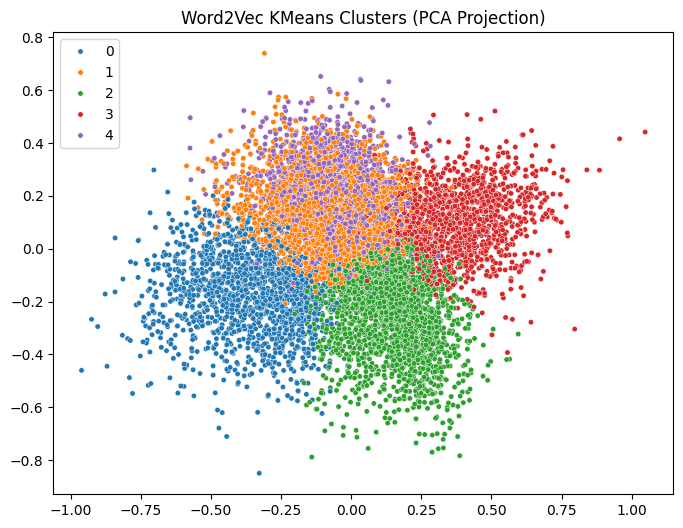

In [ ]:
# Sample for visualization (not for clustering)
sample_size = 10000   # 10k is ideal for PCA scatter
sample_idx = np.random.choice(len(review_vectors), sample_size, replace=False)

pca = PCA(n_components=2, random_state=42)
w2v_pca = pca.fit_transform(review_vectors[sample_idx])

# Fetch corresponding cluster labels
sample_clusters = clusters_w2v[sample_idx]

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=w2v_pca[:, 0],
    y=w2v_pca[:, 1],
    hue=sample_clusters,
    palette='tab10',
    s=15
)
plt.title("Word2Vec KMeans Clusters (PCA Projection)")
plt.show()


## Summary

We used Word2Vec to convert reviews into semantic vectors and applied K-Means to group similar feedback into meaningful themes.  
Cosine similarity helped us retrieve reviews with matching opinions, and PCA visualization showed how these clusters naturally form in embedding space.
